In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [44]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [45]:
# Data Augmentation

transforms.RandomHorizontalFlip(), #Flips the image left ↔ right
transforms.RandomRotation(10), #Rotates image randomly between: -10° to +10°
transforms.RandomResizedCrop(224, scale=(0.8, 1.0)) # Uses 80% to 100% of original image: Randomly zooms in/out
transforms.ColorJitter(brightness=0.2, contrast=0.2) #Makes image brighter or darker
transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)) #Moves image slightly: left/right or up/down

RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))

In [46]:
train_dataset = datasets.ImageFolder("/Users/Pooja/Documents/capstone_projects/projects/Tumor/dataset/train", transform=train_transform)
val_dataset   = datasets.ImageFolder("/Users/Pooja/Documents/capstone_projects/projects/Tumor/dataset/valid", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes

In [47]:
import torch.nn.functional as F

class BrainTumorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(128*14*14, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(x)  # 🔥 extra pooling
        
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

In [48]:
def get_resnet():
    model = models.resnet18(pretrained=True)
    
    for param in model.parameters():
        param.requires_grad = False
    
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 4)
    
    return model

In [49]:
def train_model(model, epochs=5):
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        
        # ===== TRAIN =====
        model.train()
        running_loss, correct, total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # ===== VALIDATION =====
        model.eval()
        val_loss, correct, total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        # ===== STORE =====
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, train_losses, val_losses, train_accs, val_accs

In [50]:
# Custom CNN
cnn_model = BrainTumorCNN()
cnn_model, cnn_train_loss, cnn_val_loss, cnn_train_acc, cnn_val_acc = train_model(cnn_model, epochs=7)

# ResNet
resnet_model = get_resnet()
resnet_model, res_train_loss, res_val_loss,res_train_acc, res_val_acc = train_model(resnet_model, epochs=7)

Epoch 1: Train Loss=1.9527, Train Acc=0.4749, Val Loss=0.8542, Val Acc=0.6614
Epoch 2: Train Loss=0.9897, Train Acc=0.6289, Val Loss=0.7756, Val Acc=0.6892
Epoch 3: Train Loss=0.8127, Train Acc=0.6820, Val Loss=0.6798, Val Acc=0.7689
Epoch 4: Train Loss=0.7817, Train Acc=0.7062, Val Loss=0.6378, Val Acc=0.7490
Epoch 5: Train Loss=0.7226, Train Acc=0.7204, Val Loss=0.5988, Val Acc=0.7829
Epoch 6: Train Loss=0.6793, Train Acc=0.7375, Val Loss=0.5957, Val Acc=0.7789
Epoch 7: Train Loss=0.6555, Train Acc=0.7469, Val Loss=0.6028, Val Acc=0.7829
Epoch 1: Train Loss=1.0192, Train Acc=0.6088, Val Loss=0.7545, Val Acc=0.7231
Epoch 2: Train Loss=0.6037, Train Acc=0.8071, Val Loss=0.5801, Val Acc=0.7908
Epoch 3: Train Loss=0.5296, Train Acc=0.8218, Val Loss=0.4793, Val Acc=0.8406
Epoch 4: Train Loss=0.4449, Train Acc=0.8484, Val Loss=0.4465, Val Acc=0.8367
Epoch 5: Train Loss=0.4245, Train Acc=0.8560, Val Loss=0.3865, Val Acc=0.8825
Epoch 6: Train Loss=0.3745, Train Acc=0.8714, Val Loss=0.3857, V

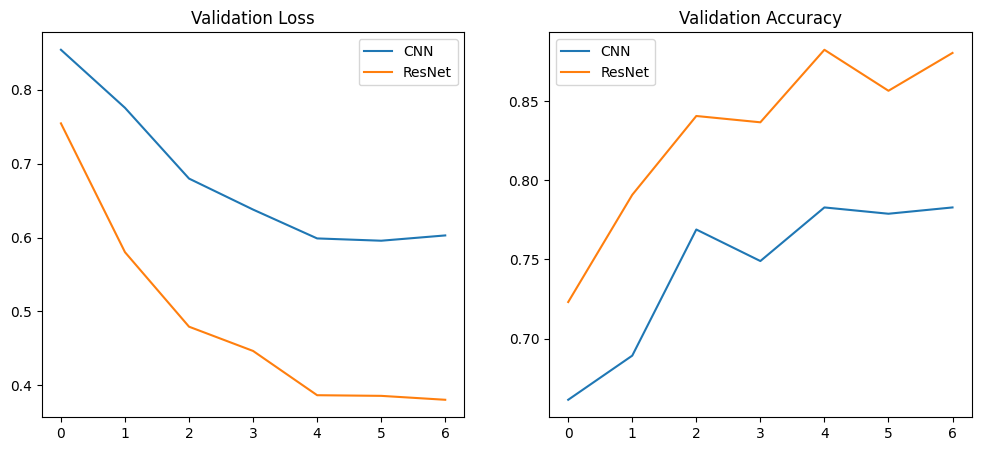

In [51]:
plt.figure(figsize=(12,5))

# Loss subplot
plt.subplot(1,2,1)
plt.plot(cnn_val_loss, label="CNN")
plt.plot(res_val_loss, label="ResNet")
plt.title("Validation Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1,2,2)
plt.plot(cnn_val_acc, label="CNN")
plt.plot(res_val_acc, label="ResNet")
plt.title("Validation Accuracy")
plt.legend()

plt.show()

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# 1. Class Weights (imbalance handling)
# ---------------------------
weights = torch.tensor([1/560, 1/360, 1/330, 1/440], dtype=torch.float)
weights = weights / weights.sum()   # normalize (recommended)
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

# ---------------------------
# 2. ResNet Model (Transfer Learning + Fine-tuning)
# ---------------------------
def get_resnet():
    model = models.resnet50(pretrained=True)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # 🔥 Unfreeze top layers (layer4)
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace final layer
    model.fc = nn.Linear(model.fc.in_features, 4)

    return model

model = get_resnet().to(device)

# ---------------------------
# 3. Optimizer (ONLY trainable params)
# ---------------------------
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4   # small LR for fine-tuning
)

# ---------------------------
# 4. Training Function (fixed version)
# ---------------------------
def train_model(model, epochs=7):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ---- TRAIN ----
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # ---- VALIDATION ----
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        # Store
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, train_losses, val_losses, train_accs, val_accs

# ---------------------------
# 5. Train
# ---------------------------
model, train_losses, val_losses, train_accs, val_accs = train_model(model, epochs=7)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/Pooja/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:07<00:00, 12.9MB/s]


Epoch 1: Train Loss=0.4288, Train Acc=0.8572, Val Loss=0.2530, Val Acc=0.9064
Epoch 2: Train Loss=0.1316, Train Acc=0.9581, Val Loss=0.1441, Val Acc=0.9582
Epoch 3: Train Loss=0.1011, Train Acc=0.9622, Val Loss=0.1550, Val Acc=0.9602
Epoch 4: Train Loss=0.0645, Train Acc=0.9805, Val Loss=0.1458, Val Acc=0.9482
Epoch 5: Train Loss=0.0631, Train Acc=0.9811, Val Loss=0.1723, Val Acc=0.9562
Epoch 6: Train Loss=0.0371, Train Acc=0.9894, Val Loss=0.1405, Val Acc=0.9582
Epoch 7: Train Loss=0.0198, Train Acc=0.9959, Val Loss=0.1099, Val Acc=0.9681


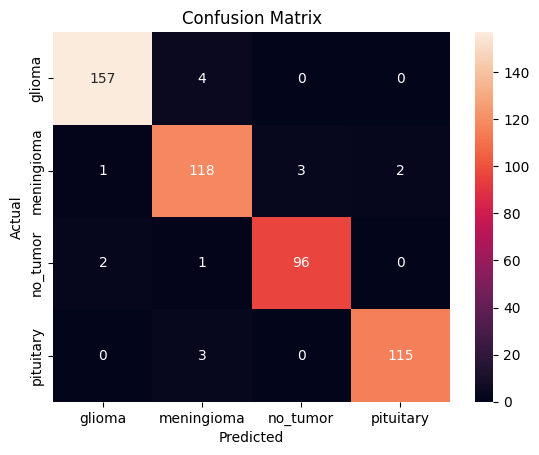

In [53]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

def plot_confusion_matrix(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
plot_confusion_matrix(model, val_loader, train_dataset.classes)

In [56]:
torch.save(model.state_dict(), "/Users/Pooja/Documents/capstone_projects/projects/Tumor/resnet_model.pth")
print("Model saved!")

Model saved!


In [57]:
model = get_resnet()   # same architecture
model.load_state_dict(torch.load("/Users/Pooja/Documents/capstone_projects/projects/Tumor/resnet_model.pth"))
model = model.to(device)
model.eval()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [58]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root="/Users/Pooja/Documents/capstone_projects/projects/Tumor/dataset/test",
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [59]:
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9634


In [60]:
from sklearn.metrics import classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:   # use test_loader ideally
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate report
report = classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
)

print(report)

              precision    recall  f1-score   support

      glioma       0.98      0.99      0.98        80
  meningioma       0.94      0.97      0.95        63
    no_tumor       0.98      0.88      0.92        49
   pituitary       0.96      1.00      0.98        54

    accuracy                           0.96       246
   macro avg       0.96      0.96      0.96       246
weighted avg       0.96      0.96      0.96       246



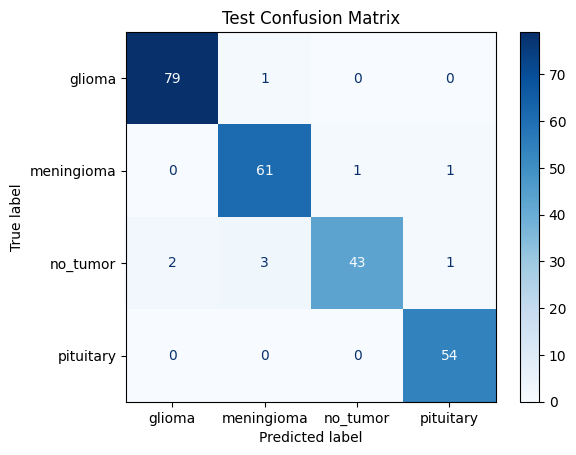

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

disp.plot(cmap="Blues")
plt.title("Test Confusion Matrix")
plt.show()

In [ ]:
plt.plot(cnn_val_acc, label="CNN Val Acc")
plt.plot(res_val_acc, label="ResNet Val Acc")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [ ]:
def plot_cm(model):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
plot_cm(cnn_model)
plot_cm(resnet_model)